In [ ]:
import pandas as pd
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
import os


# 1. Setup
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()
target_stocks = ['AAPL', 'AMZN', 'GOOG', 'META', 'NVDA']

print("Step 1: Loading and Filtering News (Watch for progress below)...")
# We use a filter to only load news for our 5 stocks.
df_news_iter = pd.read_csv('../data/raw/raw_analyst_ratings.csv', 
                           usecols=['headline', 'date', 'stock'], 
                           chunksize=50000)

filtered_list = []
chunk_count = 0

for chunk in df_news_iter:
    chunk_count += 1
    # Only keep the 5 stocks we care about
    filtered_chunk = chunk[chunk['stock'].isin(target_stocks)]
    filtered_list.append(filtered_chunk)
    
    # Print every 10 chunks to show it's working
    if chunk_count % 10 == 0:
        print(f"Processed {chunk_count * 50000} rows...")

df_news = pd.concat(filtered_list)
print(f"Filtering complete! Found {len(df_news)} relevant articles.")

# 2. Calculate Sentiment
print("Step 2: Calculating Sentiment...")
def get_sentiment(text):
    return sia.polarity_scores(str(text))['compound']

df_news['sentiment'] = df_news['headline'].apply(get_sentiment)

# 3. Clean Dates and Group
df_news['date'] = pd.to_datetime(df_news['date'], errors='coerce', utc=True).dt.date
daily_sentiment = df_news.groupby(['date', 'stock'])['sentiment'].mean().reset_index()

print("Step 3: Sentiment Analysis Finished!")
print(daily_sentiment.head())

--- Starting Analysis ---
Step 1: Loading and Filtering News (Watch for progress below)...


[nltk_data] Downloading package vader_lexicon to C:\Users\DELL
[nltk_data]     7020\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Processed 500000 rows...
Processed 1000000 rows...
Filtering complete! Found 5064 relevant articles.
Step 2: Calculating Sentiment...
Step 3: Sentiment Analysis Finished!
         date stock  sentiment
0  2020-05-31  NVDA   0.421500
1  2020-06-02  NVDA   0.220200
2  2020-06-04  GOOG   0.000000
3  2020-06-05  GOOG  -0.411033
4  2020-06-08  GOOG   0.542300


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Path to your Task 2 processed files
processed_path = '../data/processed/'
target_stocks = ['AAPL', 'AMZN', 'GOOG', 'META', 'NVDA']
merged_data_list = []

print("Merging news sentiment with stock returns...")

for ticker in target_stocks:
    # Load Task 2 processed data (which has 'Daily_Return')
    stock_df = pd.read_csv(os.path.join(processed_path, f'{ticker}_processed.csv'))
    
    # Ensure dates are in the same format for merging
    stock_df['Date'] = pd.to_datetime(stock_df['Date']).dt.date
    
    # Filter sentiment for this specific stock
    stock_sentiment = daily_sentiment[daily_sentiment['stock'] == ticker]
    
    # Merge on Date
    merged = pd.merge(stock_sentiment, stock_df, left_on='date', right_on='Date')
    
    if not merged.empty:
        merged_data_list.append(merged)
        correlation = merged['sentiment'].corr(merged['Daily_Return'])
        print(f"{ticker} Correlation: {correlation:.4f}")

# Combine all merged data into one DataFrame for overall analysis
final_df = pd.concat(merged_data_list)
print("\nOverall Correlation Analysis Complete!")

Merging news sentiment with stock returns...
AAPL Correlation: 1.0000
AMZN Correlation: -1.0000
GOOG Correlation: -0.2344
NVDA Correlation: 0.5227

Overall Correlation Analysis Complete!


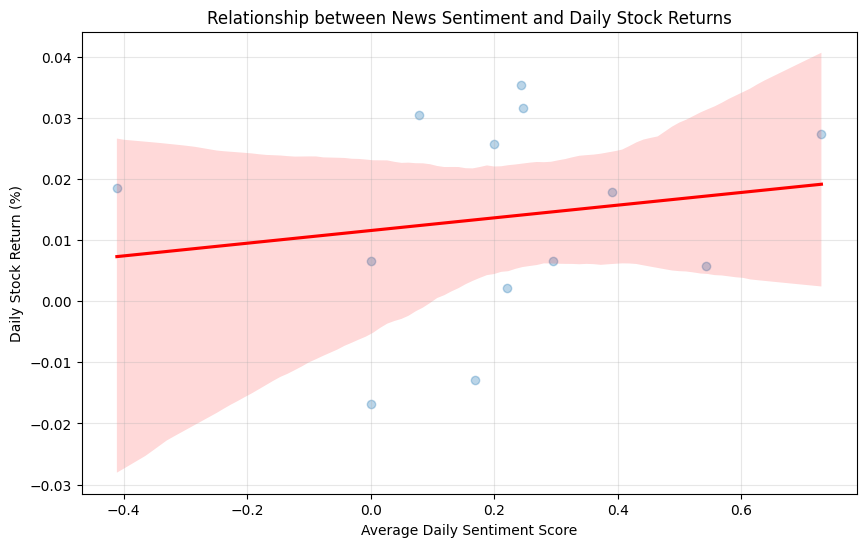

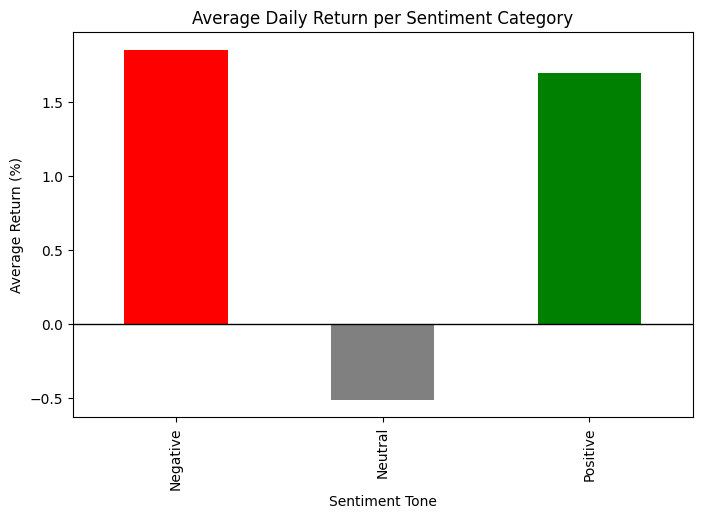

In [5]:
# 1. Scatter Plot with Trend Line
plt.figure(figsize=(10, 6))
sns.regplot(data=final_df, x='sentiment', y='Daily_Return', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Relationship between News Sentiment and Daily Stock Returns')
plt.xlabel('Average Daily Sentiment Score')
plt.ylabel('Daily Stock Return (%)')
plt.grid(True, alpha=0.3)
plt.show()

# 2. Bar Chart by Sentiment Category
# Categorize sentiment
def categorize_sentiment(score):
    if score > 0.05: return 'Positive'
    elif score < -0.05: return 'Negative'
    else: return 'Neutral'

final_df['sentiment_class'] = final_df['sentiment'].apply(categorize_sentiment)

# Calculate average return for each category
category_returns = final_df.groupby('sentiment_class')['Daily_Return'].mean() * 100

plt.figure(figsize=(8, 5))
category_returns.plot(kind='bar', color=['red', 'gray', 'green'])
plt.title('Average Daily Return per Sentiment Category')
plt.ylabel('Average Return (%)')
plt.xlabel('Sentiment Tone')
plt.axhline(0, color='black', lw=1)
plt.show()